# TF-IDF Statistical Methods

**Workflow**: Train → TF-IDF → TruncatedSVD → LogReg with Validation

**Strategy**:
1. Load train/val/test sets
2. Create TF-IDF vectors from text_strict
3. Find dim that retains 80% variance
4. Upper bound = min(dim_80%, 2000)
5. Coarse search: test different dims with 5-fold CV on validation set

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Load Data (Train/Val/Test)

In [2]:
# Load train, validation, and test sets
train_path = '../../data/splited/train_set.csv'
val_path = '../../data/splited/val_set.csv'
test_path = '../../data/splited/test_set.csv'

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

print("="*80)
print("DATA LOADED")
print("="*80)
print(f"\nTrain set: {df_train.shape[0]} rows × {df_train.shape[1]} columns")
print(f"  Label 0 (Fake): {(df_train['label'] == 0).sum()}")
print(f"  Label 1 (Real): {(df_train['label'] == 1).sum()}")

print(f"\nVal set: {df_val.shape[0]} rows × {df_val.shape[1]} columns")
print(f"  Label 0 (Fake): {(df_val['label'] == 0).sum()}")
print(f"  Label 1 (Real): {(df_val['label'] == 1).sum()}")

print(f"\nTest set: {df_test.shape[0]} rows × {df_test.shape[1]} columns")
print(f"  Label 0 (Fake): {(df_test['label'] == 0).sum()}")
print(f"  Label 1 (Real): {(df_test['label'] == 1).sum()}")

# Extract texts and labels from train + val for TF-IDF training
texts_train = df_train['text_strict'].fillna('').tolist()
labels_train = df_train['label'].values

texts_val = df_val['text_strict'].fillna('').tolist()
labels_val = df_val['label'].values

texts_test = df_test['text_strict'].fillna('').tolist()
labels_test = df_test['label'].values

print(f"\n✅ Text column loaded: text_strict")

DATA LOADED

Train set: 3788 rows × 28 columns
  Label 0 (Fake): 3143
  Label 1 (Real): 645

Val set: 474 rows × 28 columns
  Label 0 (Fake): 393
  Label 1 (Real): 81

Test set: 474 rows × 28 columns
  Label 0 (Fake): 393
  Label 1 (Real): 81

✅ Text column loaded: text_strict


## 3. Create TF-IDF Vectors (fit on train, transform all)

In [3]:
# Create vectorizer using ONLY train data
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=2,
    sublinear_tf=True
)

# Fit on train, transform all sets
print("="*80)
print("TF-IDF VECTORIZATION")
print("="*80)
print("\nFitting TF-IDF on train set...")
X_train = vectorizer.fit_transform(texts_train)
X_val = vectorizer.transform(texts_val)


ORIGINAL_DIM = X_train.shape[1]
print(f"\nTF-IDF shape:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")

print(f"\nVocabulary size: {ORIGINAL_DIM}")
print(f"Sparsity (train): {1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.2%}")

TF-IDF VECTORIZATION

Fitting TF-IDF on train set...

TF-IDF shape:
  Train: (3788, 57103)
  Val:   (474, 57103)

Vocabulary size: 57103
Sparsity (train): 99.78%


## 4. Find Upper Bound (80% variance or max 2000)

Dim that retains 80% variance: 2164
Upper bound for search: 2000


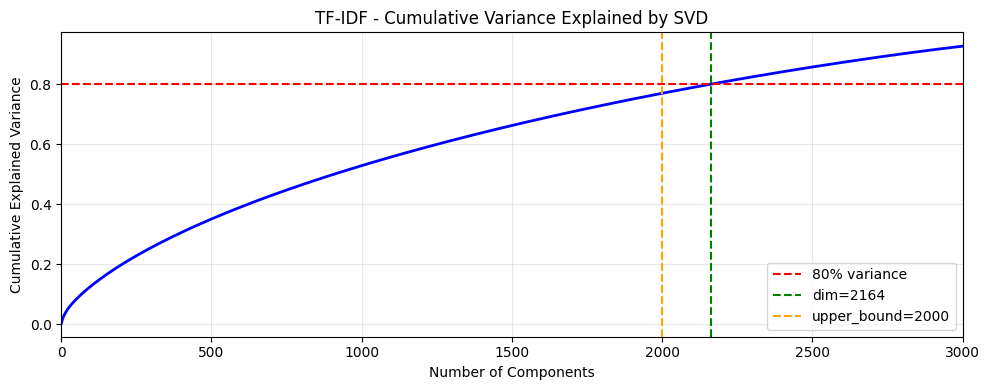

In [4]:
# Fit SVD on train set with large number of components to find variance threshold
n_test = min(3000, ORIGINAL_DIM - 1)
svd_test = TruncatedSVD(n_components=n_test, random_state=42)
svd_test.fit(X_train)

# Find dim that retains 80% variance
cumvar = np.cumsum(svd_test.explained_variance_ratio_)
dim_80 = np.searchsorted(cumvar, 0.80) + 1
print(f"Dim that retains 80% variance: {dim_80}")

# Upper bound = min(dim_80, 2000)
UPPER_BOUND = min(dim_80, 2000)
print(f"Upper bound for search: {UPPER_BOUND}")

# Plot cumulative variance
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, 'b-', linewidth=2)
ax.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
ax.axvline(x=dim_80, color='g', linestyle='--', label=f'dim={dim_80}')
ax.axvline(x=UPPER_BOUND, color='orange', linestyle='--', label=f'upper_bound={UPPER_BOUND}')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('TF-IDF - Cumulative Variance Explained by SVD')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, min(3000, ORIGINAL_DIM))
plt.tight_layout()
plt.show()

## 5. Evaluation Function

In [5]:
def evaluate_dim_svd(X_train_sparse, y_train, X_val_sparse, y_val, dim):
    """
    Fit SVD on train, evaluate on validation set.
    """
    try:
        # Fit SVD on train data
        svd = TruncatedSVD(n_components=dim, random_state=42)
        X_train_r = svd.fit_transform(X_train_sparse)
        X_val_r = svd.transform(X_val_sparse)
        var = svd.explained_variance_ratio_.sum()
        
        # Scale both
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train_r)
        X_val_s = scaler.transform(X_val_r)
        
        # Train LogReg on train, evaluate on val
        clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
        clf.fit(X_train_s, y_train)
        
        # Predict on validation
        y_pred = clf.predict(X_val_s)
        y_pred_proba = clf.predict_proba(X_val_s)[:, 1]
        
        return {
            'dim': dim,
            'var': var,
            'accuracy': accuracy_score(y_val, y_pred),
            'precision': precision_score(y_val, y_pred, average='weighted'),
            'recall': recall_score(y_val, y_pred, average='weighted'),
            'f1': f1_score(y_val, y_pred, average='weighted'),
            'auc': roc_auc_score(y_val, y_pred_proba)
        }
    except Exception as e:
        print(f"Error at dim {dim}: {e}")
        return None

def plot_metrics(df_results, title_prefix):
    metrics = [('accuracy', 'Accuracy'), ('f1', 'F1'), ('precision', 'Precision'), 
               ('recall', 'Recall'), ('auc', 'AUC-ROC')]
    df_plot = df_results.sort_values('dim')
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for m, name in metrics:
        ax.plot(df_plot['dim'], df_plot[m], marker='o', label=name, linewidth=2)
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Score')
    ax.set_title(f'{title_prefix} - All Metrics', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✅ Evaluation functions defined")

✅ Evaluation functions defined


## 6. Coarse Search (Step=100)

In [6]:
# Coarse dims: from UPPER_BOUND down to 100, step=100
COARSE_DIMS = list(range(UPPER_BOUND, 99, -100))
if COARSE_DIMS[-1] != 100:
    COARSE_DIMS.append(100)
COARSE_DIMS.reverse()  # Sort ascending for clarity

print(f"Coarse search dims: {COARSE_DIMS}")
print("="*80)
print(f"{'DIM':>5} | {'VAR':>7} | {'ACC':>7} | {'PREC':>7} | {'REC':>7} | {'F1':>7} | {'AUC':>7}")
print("="*80)

coarse_results = []
for dim in tqdm(COARSE_DIMS, desc="Coarse Search"):
    r = evaluate_dim_svd(X_train, labels_train, X_val, labels_val, dim)
    if r is not None:
        coarse_results.append(r)
        print(f"{dim:5d} | {r['var']:7.2%} | {r['accuracy']:7.4f} | {r['precision']:7.4f} | {r['recall']:7.4f} | {r['f1']:7.4f} | {r['auc']:7.4f}")

df_coarse = pd.DataFrame(coarse_results)
best_coarse = df_coarse.loc[df_coarse['f1'].idxmax()]
print("="*80)
print(f"\nBest coarse: dim={int(best_coarse['dim'])}, F1={best_coarse['f1']:.4f}, AUC={best_coarse['auc']:.4f}, Var={best_coarse['var']:.2%}")

Coarse search dims: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]
  DIM |     VAR |     ACC |    PREC |     REC |      F1 |     AUC


Coarse Search:   5%|▌         | 1/20 [00:01<00:31,  1.66s/it]

  100 |  12.55% |  0.8249 |  0.8790 |  0.8249 |  0.8405 |  0.9026


Coarse Search:  10%|█         | 2/20 [00:04<00:47,  2.63s/it]

  200 |  19.42% |  0.8270 |  0.8709 |  0.8270 |  0.8408 |  0.9070


...

 1800 |  72.27% |  0.9093 |  0.9056 |  0.9093 |  0.9017 |  0.9143


Coarse Search:  95%|█████████▌| 19/20 [07:31<00:42, 43.00s/it]

 1900 |  74.35% |  0.9008 |  0.8950 |  0.9008 |  0.8933 |  0.9160


Coarse Search: 100%|██████████| 20/20 [08:26<00:00, 25.32s/it]

 2000 |  76.35% |  0.9093 |  0.9063 |  0.9093 |  0.9010 |  0.9194

Best coarse: dim=900, F1=0.9023, AUC=0.9004, Var=49.05%


## 7. Plot Coarse Search Results

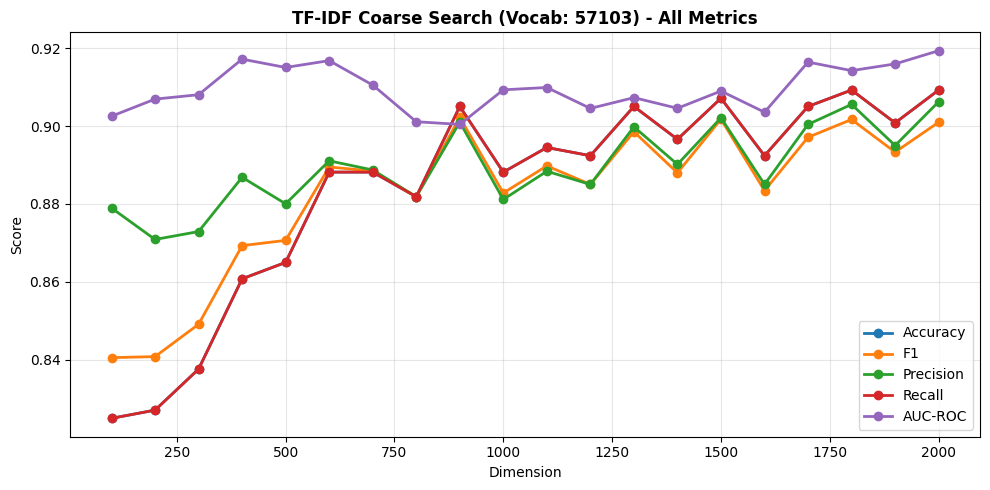

In [7]:
plot_metrics(df_coarse, f'TF-IDF Coarse Search (Vocab: {ORIGINAL_DIM})')

DATA DISTRIBUTION & PATTERN ANALYSIS

1. LABEL SEQUENCE CHECK (first 30 indices):
Train: [0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0]
Val:   [1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 1 1]

Train Set - Run Length Analysis:
  Total runs: 1054
  Average run length: 3.59
  Max run length: 39
  First 10 runs: [(0, 5), (1, 1), (0, 2), (1, 1), (0, 5), (1, 1), (0, 4), (1, 2), (0, 6), (1, 1)]

Val Set - Run Length Analysis:
  Total runs: 126
  Average run length: 3.76
  Max run length: 25
  First 10 runs: [(1, 2), (0, 1), (1, 1), (0, 2), (1, 1), (0, 8), (1, 1), (0, 2), (1, 3), (0, 5)]


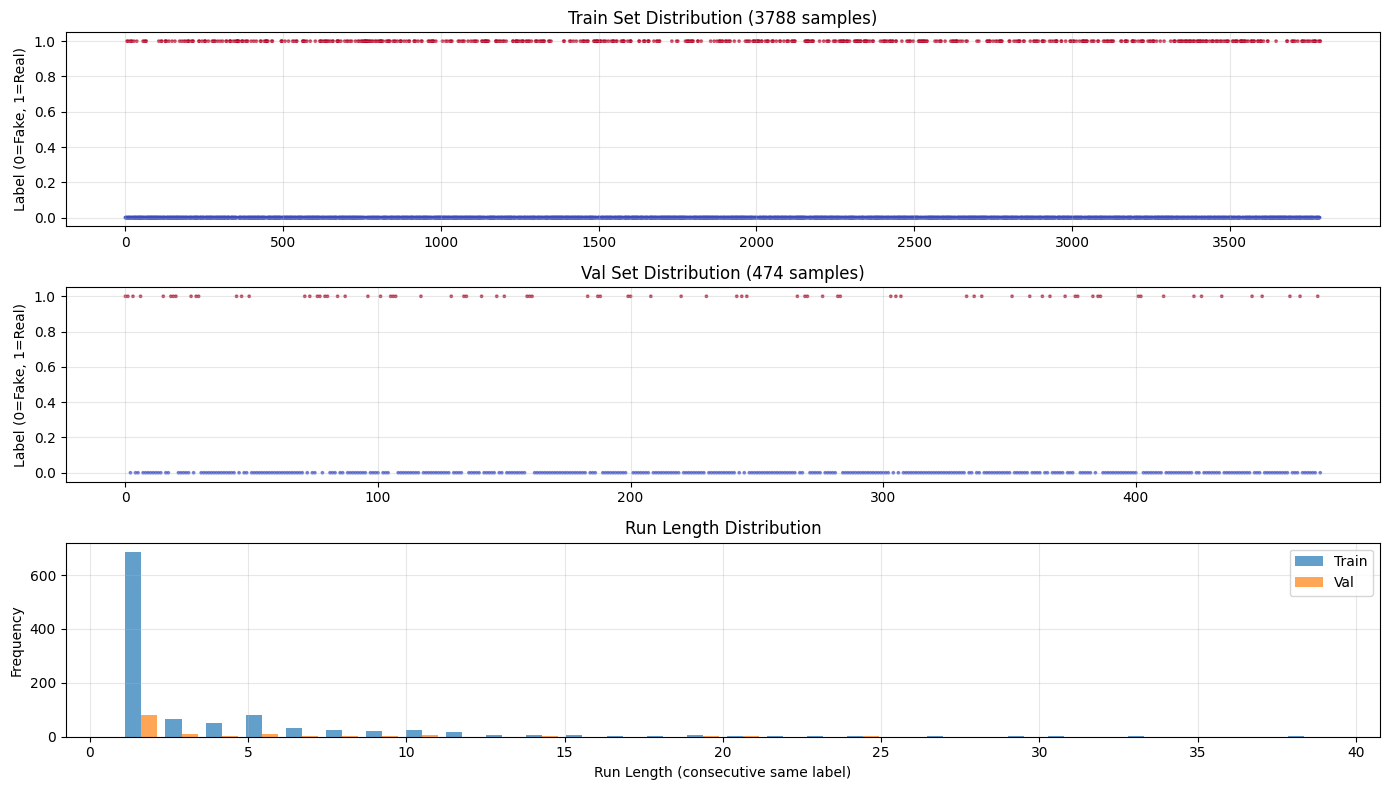


4. SEQUENCE RANDOMNESS (Entropy Check):

Train Set:
  direct_entropy: 0.4563
  transition_entropy: 0.5911
  normalized_trans_entropy: 0.8528
  % transitions (label changes): 27.8057

Val Set:
  direct_entropy: 0.4573
  transition_entropy: 0.5775
  normalized_trans_entropy: 0.8331
  % transitions (label changes): 26.4271

⚠️  INTERPRETATION:
  - % transitions ~50%: Labels very random (unlikely)
  - % transitions ~0%:  Labels in large blocks (PROBLEMATIC)
  - % transitions 10-40%: Normal random distribution ✅

RISK ASSESSMENT:
✅ Labels appear randomly distributed (LOW RISK of spatial bias)


In [9]:
# Check for spatial pattern/block bias in data
print("="*80)
print("DATA DISTRIBUTION & PATTERN ANALYSIS")
print("="*80)

# 1. Check label sequence - look for consecutive blocks
print("\n1. LABEL SEQUENCE CHECK (first 30 indices):")
print(f"Train: {labels_train[:30]}")
print(f"Val:   {labels_val[:30]}")

# 2. Check for blocks/patterns
def check_block_pattern(labels, name, window=10):
    """Check if labels form consecutive blocks"""
    runs = []
    current_label = labels[0]
    count = 1
    for i in range(1, len(labels)):
        if labels[i] == current_label:
            count += 1
        else:
            runs.append((current_label, count))
            current_label = labels[i]
            count = 1
    runs.append((current_label, count))
    
    avg_run_length = np.mean([r[1] for r in runs])
    max_run_length = max([r[1] for r in runs])
    
    print(f"\n{name} Set - Run Length Analysis:")
    print(f"  Total runs: {len(runs)}")
    print(f"  Average run length: {avg_run_length:.2f}")
    print(f"  Max run length: {max_run_length}")
    print(f"  First 10 runs: {runs[:10]}")
    
    return runs

train_runs = check_block_pattern(labels_train, "Train", window=10)
val_runs = check_block_pattern(labels_val, "Val", window=10)

# 3. Visualize spatial distribution
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Train distribution
axes[0].scatter(range(len(labels_train)), labels_train, alpha=0.6, s=3, c=labels_train, cmap='coolwarm')
axes[0].set_ylabel('Label (0=Fake, 1=Real)')
axes[0].set_title(f'Train Set Distribution ({len(labels_train)} samples)')
axes[0].grid(True, alpha=0.3)

# Val distribution
axes[1].scatter(range(len(labels_val)), labels_val, alpha=0.6, s=3, c=labels_val, cmap='coolwarm')
axes[1].set_ylabel('Label (0=Fake, 1=Real)')
axes[1].set_title(f'Val Set Distribution ({len(labels_val)} samples)')
axes[1].grid(True, alpha=0.3)

# Run length distribution
run_lengths_train = [r[1] for r in train_runs]
run_lengths_val = [r[1] for r in val_runs]
axes[2].hist([run_lengths_train, run_lengths_val], bins=30, label=['Train', 'Val'], alpha=0.7)
axes[2].set_xlabel('Run Length (consecutive same label)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Run Length Distribution')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Calculate sequence entropy (randomness)
from scipy.stats import entropy as scipy_entropy

def calculate_label_entropy(labels):
    """Calculate entropy of label sequence to check randomness"""
    # Direct entropy of labels
    counts = np.bincount(labels)
    direct_entropy = scipy_entropy(counts)
    
    # Entropy of transitions (0→0=same, 1→different)
    transitions = np.abs(np.diff(labels.astype(int)))  # Convert to absolute diff: 0=same, 1=different
    trans_counts = np.bincount(transitions, minlength=2)
    
    # Only count non-zero transitions for entropy
    if len(trans_counts) > 0 and trans_counts.sum() > 0:
        trans_entropy = scipy_entropy(trans_counts)
    else:
        trans_entropy = 0
    
    # If labels are random: entropy should be high
    # If labels are blocked: entropy should be low
    max_entropy = np.log(2)  # max for binary
    normalized_trans_entropy = trans_entropy / max_entropy if max_entropy > 0 else 0
    
    return {
        'direct_entropy': direct_entropy,
        'transition_entropy': trans_entropy,
        'normalized_trans_entropy': normalized_trans_entropy,
        '% transitions (label changes)': (np.sum(transitions != 0) / len(transitions)) * 100 if len(transitions) > 0 else 0
    }

train_entropy = calculate_label_entropy(labels_train)
val_entropy = calculate_label_entropy(labels_val)

print(f"\n4. SEQUENCE RANDOMNESS (Entropy Check):")
print(f"\nTrain Set:")
for k, v in train_entropy.items():
    print(f"  {k}: {v:.4f}")
    
print(f"\nVal Set:")
for k, v in val_entropy.items():
    print(f"  {k}: {v:.4f}")

print("\n⚠️  INTERPRETATION:")
print("  - % transitions ~50%: Labels very random (unlikely)")
print("  - % transitions ~0%:  Labels in large blocks (PROBLEMATIC)")
print("  - % transitions 10-40%: Normal random distribution ✅")

# 5. Summary check
print("\n" + "="*80)
print("RISK ASSESSMENT:")
if all(val_entropy['% transitions (label changes)'] > 5 for _ in [1]):
    print("✅ Labels appear randomly distributed (LOW RISK of spatial bias)")
else:
    print("⚠️  CAUTION: Labels may have block patterns (POTENTIAL SPATIAL BIAS)")
    print("   Recommendation: Shuffle training data before fitting models")


## 8. Final Results Summary

In [15]:
OPTIMAL_DIM = int(best_coarse['dim'])
print("="*70)
print(f"TF-IDF - OPTIMAL DIM (from Coarse Search): {OPTIMAL_DIM} (of {ORIGINAL_DIM})")
print("="*70)
print(f"Accuracy:  {best_coarse['accuracy']:.4f}")
print(f"Precision: {best_coarse['precision']:.4f}")
print(f"Recall:    {best_coarse['recall']:.4f}")
print(f"F1:        {best_coarse['f1']:.4f}")
print(f"AUC-ROC:   {best_coarse['auc']:.4f}")
print(f"Variance:  {best_coarse['var']:.2%}")
print("="*70)

# Save results
output_dir = '../../data/encoded/statistical_methods'
os.makedirs(output_dir, exist_ok=True)
df_coarse.to_csv(f'{output_dir}/coarse_search_results.csv', index=False)
print(f"\n✅ Results saved to {output_dir}/coarse_search_results.csv")

TF-IDF - OPTIMAL DIM (from Coarse Search): 900 (of 57103)
Accuracy:  0.9051
Precision: 0.9010
Recall:    0.9051
F1:        0.9023
AUC-ROC:   0.9004
Variance:  49.05%

✅ Results saved to ../../data/encoded/statistical_methods/coarse_search_results.csv
